In [2]:
import warnings



In [3]:

warnings.filterwarnings("ignore")



In [4]:

import pandas as pd


In [5]:

import numpy as np


In [6]:

from sklearn.datasets import load_iris


In [7]:

from sklearn.preprocessing import StandardScaler



In [8]:

# Load raw Iris dataset
raw_iris = load_iris()


In [9]:

features = raw_iris.feature_names


In [10]:

X_raw = raw_iris.data


In [11]:

y_true = raw_iris.target




In [12]:

# Standardize the features
scaler = StandardScaler()


In [13]:

X_scaled = scaler.fit_transform(X_raw)



In [14]:


# Store in a DataFrame for visualization
iris_df = pd.DataFrame(data=X_scaled, columns=features)


In [15]:

iris_df['species_id'] = y_true


In [16]:

species_map = {i: name for i, name in enumerate(raw_iris.target_names)}


In [17]:

iris_df['species_name'] = iris_df['species_id'].map(species_map)



In [18]:

print("Standardized dataset dimensions:", X_scaled.shape)


Standardized dataset dimensions: (150, 4)


In [19]:

print("\nFirst 3 rows of standardized dataset:")



First 3 rows of standardized dataset:


In [20]:

print(iris_df.head(3))

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.900681          1.019004          -1.340227         -1.315444   
1          -1.143017         -0.131979          -1.340227         -1.315444   
2          -1.385353          0.328414          -1.397064         -1.315444   

   species_id species_name  
0           0       setosa  
1           0       setosa  
2           0       setosa  


In [21]:
# Calculate the covariance matrix
cov_matrix = np.cov(X_scaled.T)


In [22]:

print("Covariance Matrix:\n", cov_matrix)



Covariance Matrix:
 [[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


In [23]:

# Perform eigenvalue decomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)


In [24]:

print("\nEigenvalues (Variance components):\n", eigenvalues)



Eigenvalues (Variance components):
 [2.93808505 0.9201649  0.14774182 0.02085386]


In [25]:

print("\nEigenvectors (Principal Axes):\n", eigenvectors)



Eigenvectors (Principal Axes):
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


In [26]:
from sklearn.decomposition import PCA



In [27]:

pca_model = PCA(n_components=2, random_state=42)


In [28]:

X_pca = pca_model.fit_transform(X_scaled)



In [29]:

# Convert to a DataFrame
pca_df = pd.DataFrame(data=X_pca, columns=['PC_1', 'PC2'])


In [30]:

pca_df['species_name'] = iris_df['species_name']




In [31]:

print("Transformed PCA space dimensions:", X_pca.shape)


Transformed PCA space dimensions: (150, 2)


In [32]:

print("\nFirst 3 projected coordinates:")




First 3 projected coordinates:


In [33]:

print(pca_df.head(3))


       PC_1       PC2 species_name
0 -2.264703  0.480027       setosa
1 -2.080961 -0.674134       setosa
2 -2.364229 -0.341908       setosa


In [34]:
import matplotlib.pyplot as plt


In [35]:

import seaborn as sns



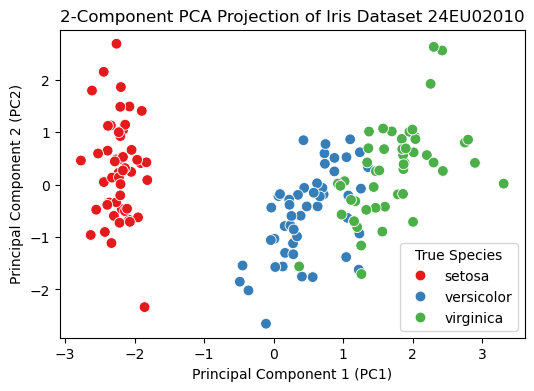

In [36]:


plt.figure(figsize=(6, 4))
sns.scatterplot(data=pca_df, x='PC_1', y='PC2', hue='species_name', palette='Set1', s=60)
plt.title("2-Component PCA Projection of Iris Dataset 24EU02010")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title='True Species')
plt.show()


In [37]:
explained_variance = pca_model.explained_variance_ratio_


In [38]:

cumulative_variance = np.sum(explained_variance)



In [39]:


print("Explained Variance per Component:")


Explained Variance per Component:


In [40]:

for i, var in enumerate(explained_variance):
    print(f"  PC{i+1}: {var*100:.2f}%")



  PC1: 72.96%
  PC2: 22.85%


In [41]:


print(f"\nTotal Cumulative Variance Retained by 2 Components: {cumulative_variance*100:.2f}%")


Total Cumulative Variance Retained by 2 Components: 95.81%


In [42]:
# Step 1: Import required libraries
import numpy as np



In [43]:

import pandas as pd



In [44]:

import matplotlib.pyplot as plt



In [45]:


from sklearn.datasets import load_iris


In [46]:

from sklearn.model_selection import train_test_split


In [47]:

from sklearn.preprocessing import StandardScaler


In [48]:

from sklearn.decomposition import PCA


In [49]:

from sklearn.linear_model import LogisticRegression


In [50]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix




In [51]:



iris = load_iris()



In [52]:

X = iris.data                 # Input features


In [53]:

y = iris.target               # Target labels


In [54]:

feature_names = iris.feature_names


In [55]:

target_names = iris.target_names



In [56]:


print("Dataset Shape:", X.shape)


Dataset Shape: (150, 4)


In [57]:

print("Features:", feature_names)


Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [58]:
print("Classes:", target_names)




Classes: ['setosa' 'versicolor' 'virginica']


In [59]:
# ============================================================
# Step 3: Split the Dataset
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)




In [60]:
# ============================================================
# Step 4: Feature Scaling
# ============================================================

scaler = StandardScaler()


In [61]:




X_train_scaled = scaler.fit_transform(X_train)


In [62]:

X_test_scaled = scaler.transform(X_test)




In [63]:



# ============================================================
# PART A: CLASSIFICATION WITHOUT PCA
# ============================================================

print("\n========================================")


In [64]:

print("CLASSIFICATION WITHOUT PCA")
print("========================================")


CLASSIFICATION WITHOUT PCA


In [65]:
# Create Logistic Regression model
model_without_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)



In [66]:

# Train the model
model_without_pca.fit(
    X_train_scaled,
    y_train
)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [67]:
# Predict test data
y_pred_without_pca = model_without_pca.predict(
    X_test_scaled
)



In [68]:
# Calculate accuracy
accuracy_without_pca = accuracy_score(
    y_test,
    y_pred_without_pca
)



In [69]:
print("Accuracy without PCA:",
      accuracy_without_pca)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_without_pca,
        target_names=target_names
    )
)



Accuracy without PCA: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [70]:
# ============================================================
# PART B: CLASSIFICATION WITH PCA
# ============================================================

print("\n========================================")
print("CLASSIFICATION WITH PCA")
print("========================================")

# Apply PCA
pca = PCA(
    n_components=2
)




CLASSIFICATION WITH PCA


In [71]:
# Fit PCA only on training data
X_train_pca = pca.fit_transform(
    X_train_scaled
)



In [72]:
# Transform test data using the same PCA
X_test_pca = pca.transform(
    X_test_scaled
)



In [73]:
# Display explained variance
print("Explained Variance Ratio:",
      pca.explained_variance_ratio_)



Explained Variance Ratio: [0.72677234 0.23066667]


In [74]:
print("Total Explained Variance:",
      pca.explained_variance_ratio_.sum())




Total Explained Variance: 0.9574390106545365


In [75]:


# Create Logistic Regression model
model_with_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)



In [76]:




# Train the model using PCA features
model_with_pca.fit(
    X_train_pca,
    y_train
)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [77]:
# Predict test data
y_pred_with_pca = model_with_pca.predict(
    X_test_pca
)



In [78]:
# Calculate accuracy
accuracy_with_pca = accuracy_score(
    y_test,
    y_pred_with_pca
)



In [79]:
print("Accuracy with PCA:",
      accuracy_with_pca)



Accuracy with PCA: 0.9


In [80]:
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_with_pca,
        target_names=target_names
    )
)





Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [81]:
# ============================================================
# PART C: COMPARE BOTH MODELS
# ============================================================

print("\n========================================")
print("COMPARISON")
print("========================================")




COMPARISON


In [82]:
comparison = pd.DataFrame({
    "Method": [
        "Without PCA",
        "With PCA"
    ],
    "Number of Features": [
        X_train_scaled.shape[1],
        X_train_pca.shape[1]
    ],
    "Accuracy": [
        accuracy_without_pca,
        accuracy_with_pca
    ]
})



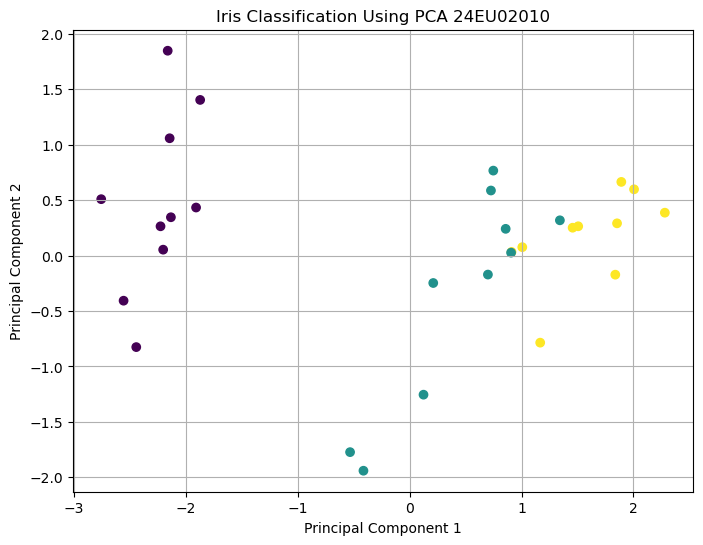

In [83]:


# ============================================================
# PART D: VISUALIZE PCA FEATURES
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_test
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Classification Using PCA 24EU02010")
plt.grid()

plt.show()

In [84]:
import warnings


In [85]:

warnings.filterwarnings("ignore")




In [86]:


from sklearn.cluster import KMeans


In [87]:
import matplotlib.pyplot as plt



In [88]:
wcss = []


In [89]:
k_range = range(1, 11)



In [90]:
# Fit K-Means iteratively
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)



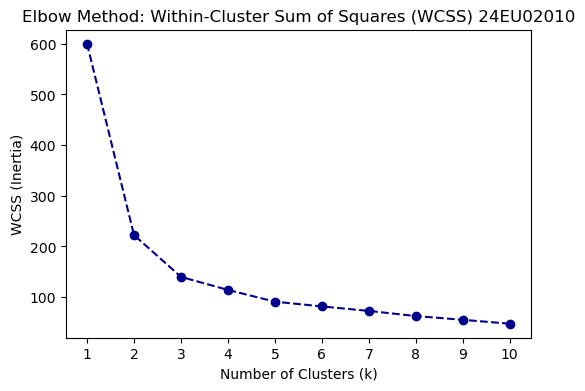

In [91]:
# Plot the Elbow Curve
plt.figure(figsize=(6, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='darkblue')
plt.title("Elbow Method: Within-Cluster Sum of Squares (WCSS) 24EU02010")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(k_range)
plt.show()


In [92]:
from sklearn.metrics import silhouette_score



In [93]:
silhouette_scores = []


In [94]:
k_eval = range(2, 6)



In [95]:
# Calculate silhouette scores for different cluster counts
for k in k_eval:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(score)



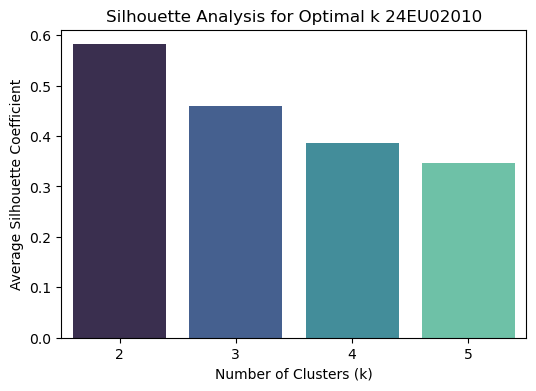

In [96]:
# Plot Silhouette scores
plt.figure(figsize=(6, 4))
sns.barplot(x=list(k_eval), y=silhouette_scores, palette='mako')
plt.title("Silhouette Analysis for Optimal k 24EU02010")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Average Silhouette Coefficient")
plt.show()



In [97]:
# Find and print the best k
best_k = k_eval[np.argmax(silhouette_scores)]


In [98]:
print(f"k = {best_k} yielded the highest silhouette coefficient ({max(silhouette_scores):.4f}).")

k = 2 yielded the highest silhouette coefficient (0.5818).


In [99]:
kmeans_raw = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)


In [100]:
kmeans_raw_labels = kmeans_raw.fit_predict(X_scaled)



In [101]:
# Append cluster labels to main DataFrame
iris_df['cluster_raw'] = kmeans_raw_labels


In [102]:
print("K-Means clustering complete. First 5 sample allocations:")



K-Means clustering complete. First 5 sample allocations:


In [103]:
print(iris_df[['species_name', 'cluster_raw']].head(5))

  species_name  cluster_raw
0       setosa            1
1       setosa            1
2       setosa            1
3       setosa            1
4       setosa            1


In [104]:
# Extract raw centroid coordinates in standardized space
raw_centroids_scaled = kmeans_raw.cluster_centers_



In [105]:
# Inverse transform centroids back to original physical measurements (cm)
raw_centroids_physical = scaler.inverse_transform(raw_centroids_scaled)

# Store in a summary table


In [106]:
centroids_df = pd.DataFrame(data=raw_centroids_physical, columns=features)


In [107]:
centroids_df.index = [f"Cluster_{i}" for i in range(3)]



In [108]:
print("--- Estimated Cluster Centroids (Original Physical Units - cm) ---")


--- Estimated Cluster Centroids (Original Physical Units - cm) ---


In [109]:
print(centroids_df)

           sepal length (cm)  sepal width (cm)  petal length (cm)  \
Cluster_0           5.799612          2.653772           4.382414   
Cluster_1           4.992043          3.429444           1.471740   
Cluster_2           6.792945          3.087827           5.524364   

           petal width (cm)  
Cluster_0          1.418814  
Cluster_1          0.251935  
Cluster_2          1.977790  


In [110]:
plt.figure(figsize=(6, 4))



<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

In [111]:
# Convert standardized centroids to original units for plotting
raw_data = scaler.inverse_transform(X_scaled)



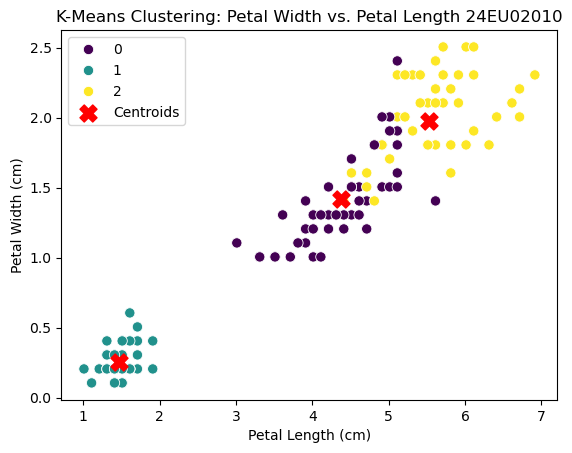

In [112]:
# Plot the continuous data points colored by cluster assignment
sns.scatterplot(x=raw_data[:, 2], y=raw_data[:, 3], hue=kmeans_raw_labels, palette='viridis', s=55, legend='full')
# Plot the calculated centroids on the same canvas
plt.scatter(
    raw_centroids_physical[:, 2], 
    raw_centroids_physical[:, 3], 
    color='red', 
    marker='X', 
    s=150, 
    label='Centroids'
)

plt.title("K-Means Clustering: Petal Width vs. Petal Length 24EU02010")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend()
plt.show()



In [113]:
import warnings


In [114]:
warnings.filterwarnings("ignore")



In [115]:
from sklearn.cluster import KMeans



In [116]:
# Train a separate K-Means model on the 2-Component PCA space
kmeans_pca = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)


In [117]:
kmeans_pca_labels = kmeans_pca.fit_predict(X_pca)



In [118]:
# Append to main DataFrame
iris_df['cluster_pca'] = kmeans_pca_labels


In [119]:
print("PCA space K-Means clustering completed successfully.")

PCA space K-Means clustering completed successfully.


In [120]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score



In [121]:
# Compute internal metrics for raw space clusters
sil_raw = silhouette_score(X_scaled, kmeans_raw_labels)


In [122]:
ch_raw = calinski_harabasz_score(X_scaled, kmeans_raw_labels)



In [123]:
# Compute internal metrics for PCA-reduced space clusters
sil_pca = silhouette_score(X_pca, kmeans_pca_labels)


In [124]:
ch_pca = calinski_harabasz_score(X_pca, kmeans_pca_labels)



In [125]:
print("--- Internal Validation (Unsupervised Quality Metrics) ---")



--- Internal Validation (Unsupervised Quality Metrics) ---


In [126]:
print(f"Raw 4D Feature Space  -> Silhouette Score: {sil_raw:.4f} | Calinski-Harabasz: {ch_raw:.2f}")


Raw 4D Feature Space  -> Silhouette Score: 0.4599 | Calinski-Harabasz: 241.90


In [127]:
print(f"PCA 2D Reduced Space -> Silhouette Score: {sil_pca:.4f} | Calinski-Harabasz: {ch_pca:.2f}")

PCA 2D Reduced Space -> Silhouette Score: 0.5092 | Calinski-Harabasz: 293.86


In [128]:
import matplotlib.pyplot as plt


In [129]:
import seaborn as sns



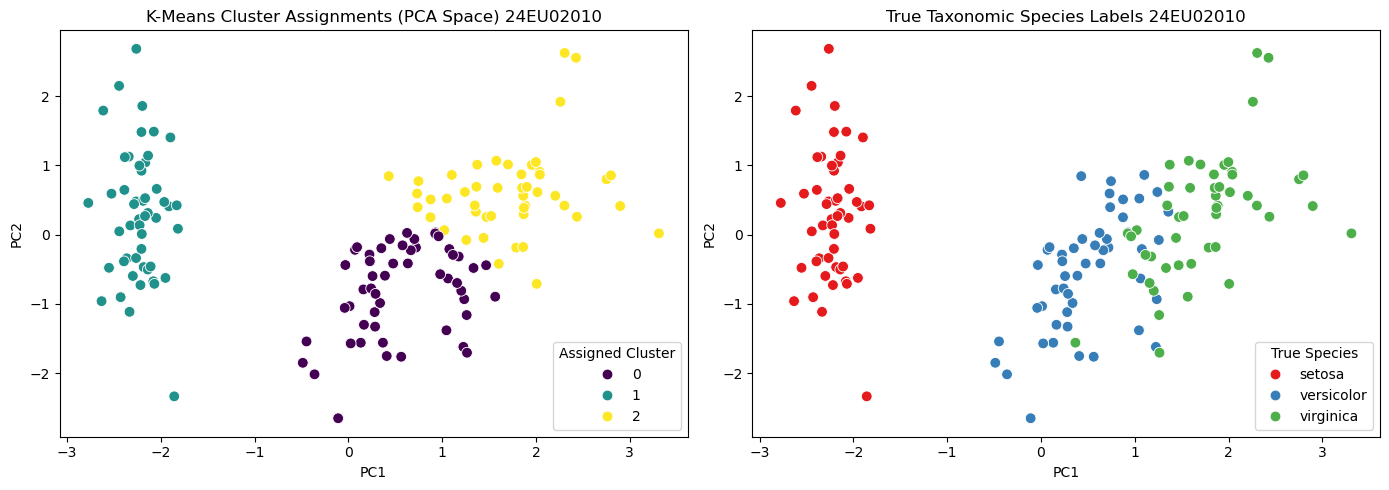

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: PCA Coordinates colored by K-Means cluster allocations
sns.scatterplot(
    data=pca_df, x='PC_1', y='PC2', hue=kmeans_pca_labels, 
    palette='viridis', s=60, ax=axes[0]
)
axes[0].set_title("K-Means Cluster Assignments (PCA Space) 24EU02010")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(title='Assigned Cluster')

# Plot 2: PCA Coordinates colored by true species labels
sns.scatterplot(
    data=pca_df, x='PC_1', y='PC2', hue='species_name', 
    palette='Set1', s=60, ax=axes[1]
)
axes[1].set_title("True Taxonomic Species Labels 24EU02010")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(title='True Species')

plt.tight_layout()
plt.show()

In [132]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari_raw = adjusted_rand_score(y_true, kmeans_raw_labels)
nmi_raw = normalized_mutual_info_score(y_true, kmeans_raw_labels)

ari_pca = adjusted_rand_score(y_true, kmeans_pca_labels)
nmi_pca = normalized_mutual_info_score(y_true, kmeans_pca_labels)

comparison_metrics = pd.DataFrame(
    data=[
        [sil_raw, ch_raw, ari_raw, nmi_raw],
        [sil_pca, ch_pca, ari_pca, nmi_pca]
    ],
    columns=['Silhouette_Score', 'Calinski_Harabasz', 'Adjusted_Rand_Index', 'Normalized_Mutual_Info'],
    index=['Standardized Raw Space (4D)', 'PCA Reduced Space (2D)']
)